**Project 3: Predicting the World Happiness Index**
Omar Bruce
DATA 101
Professor Hossein Zare


**Introduction**

How accurately can we predict a country's World Happiness Index score based on economic and social factors? 

The World Happiness Report is a collaboration between the University of Oxford, Gallup, and the United Nations(Helliwell et al.). It uses surveys to rank countries according to the self-reported level of happiness of their citizens. Additional data and survey responses are collected in order to determine which factors contribute the most to the happiness score in each country. This data analysis will use a selection of the data collected for the 2019 report. The purpose is to determine how much of the world happiness score can be determined using these features. This data is appropriate because it come directly from the source of the report, includes a number of independent variables for analysis, is of a large enough sample size, and includes all numerical data. 

This analysis will be using the following columns from the data: GDP per capita, social support, healthy life expectancy, freedom to make life choices, generosity, and perceptions of corruption. They relate to my research question because they are collected alongside the world happiness score in the report, and are relevant factors when trying to explain the level of happiness in each country. 

**Supervised/Unsupervised Learning**

For this analysis I will be using Multiple Linear Regression. The reason for this method is because I am determining the effect of multiple features on a continuous target variable. First I will run the regression using all six features to establish a baseline. Then I will be running PCA to reduce my components down to four, based on the scree plot found below. Four principle components will yield an explained variance ration of approximately 90%. In the heatmap below you can see which features are used more or less in each principal component. It is interesting to note that PC1 has positive loadings across all features, none of them over .5. Each of the other five principal components captures a different feature with a strong positve, each of those over .7. These five also mostly capture a pair of features each, like PC6 with GDP and life expectancy, PC4 with freedom and generosity. 

Baseline R-Squared with all six features: .6018
R-Squared after PCA feature reduction: .6091

From the regression analysis the answer to the research question is clear: Yes, you can accurately predict a country's Wold Happiness Index score based on economic and social factors. We can also conclude based on the two scores being nearly identical that not all of the factors are equally important when predicting the happiness score. 

**Conclusion and Future Directions**

A couple of conclusions can be drawn from this analysis. The first is that these features do predict the world happiness score well. An R-Squared score of around .6 tells us the independent variables do predict the target variable fairly strongly. Comparing the two R-Squared values says that PCA worked well to approximate the full feature set with two fewer components. In fact a change in R-Squared from .6018 to .6091 was a small increase, although this can be attributed to the randomness of our training data sets. 

The future direction for this analysis is simple: can that approximately .6 R-Squared be raised any higher? Is there more explanatory economic data that can be included, or perhaps additional survey questions that capture cultural differences(Cooper and Elmjouie)? Perhaps there are other X-factors that can be accounted for, things like conflicts and mass migration, or even sporting victories in the Olympics or FIFA World Cup. There is also the subjectivity of self-reported scores, the report could consider using more objective data to predict happiness. 


**Works Cited**

Helliwell, John F., et al., editors. "World Happiness Report 2024: Table." The World Happiness Report, 20 Mar. 2024, data.worldhappiness.report/table.

Cooper, Richard, and Yara Elmjouie. "Are These Really the World’s Happiest Countries?" Al Jazeera, 18 Aug. 2023, www.aljazeera.com/features/2023/8/18/are-these-really-the-worlds-happiest-countries.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA

In [10]:
df = pd.read_csv('2019.csv')

In [11]:
#Select appropriate features and standardize. 

features = ['GDP per capita', 'Social support', 'Healthy life expectancy', 
            'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']
X = df[features]
y = df['Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model 1: Multiple Regression with all features. 

In [12]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred = lin_reg.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
print(f" R-Squared value with all features: {r2: .4f}")


 R-Squared value with all features:  0.6018


Model 2: Multiple Linear Regression with PCA

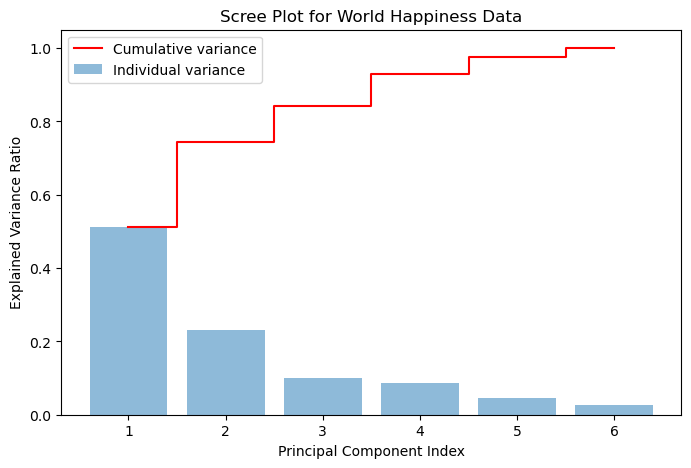

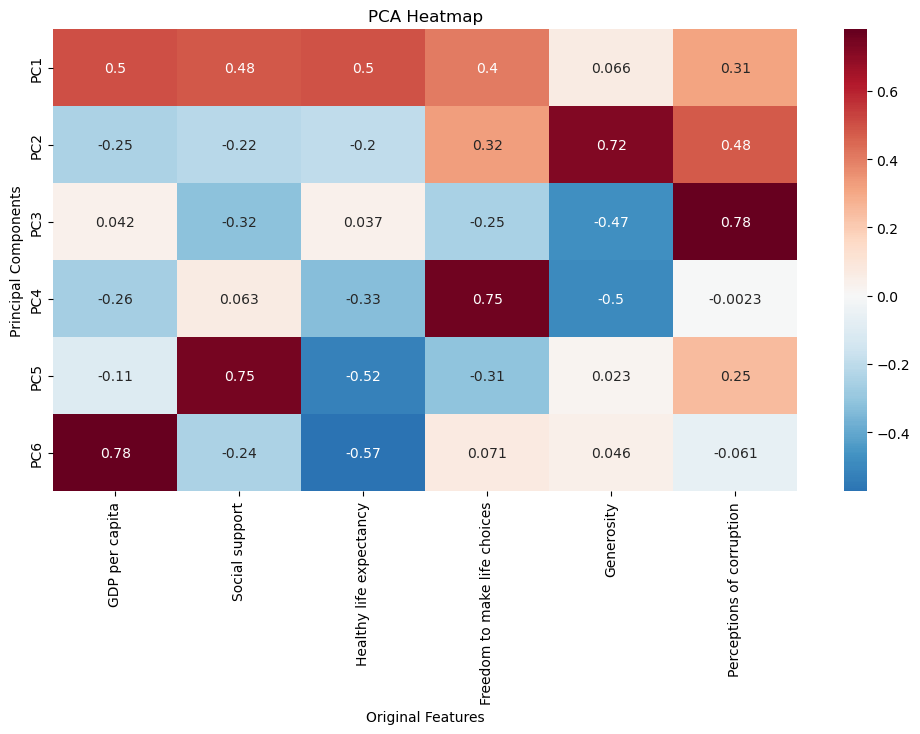

In [17]:
#create Scree Plot to choose number of components. 

pca = PCA()
pca.fit(X_train_scaled)

evr = pca.explained_variance_ratio_
cvr = np.cumsum(evr)

plt.figure(figsize=(8, 5))
plt.bar(range(1, 7), evr, alpha=0.5, align='center', label='Individual variance')
plt.step(range(1, 7), cvr, where='mid', label='Cumulative variance', color='red')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.legend(loc='best')
plt.title('Scree Plot for World Happiness Data')
plt.show()

#produce a heatmap with the princpal components

loadings = pd.DataFrame(
    pca.components_, 
    columns=X.columns, 
    index=[f'PC{i+1}' for i in range(len(pca.components_))]
)

plt.figure(figsize=(12, 6))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0)
plt.title('PCA Heatmap')
plt.xlabel('Original Features')
plt.ylabel('Principal Components')
plt.show()


In [19]:
#Data Transformation using PCA
pca_final = PCA(n_components=4)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

#Train the model using PCA components
mlr_pca = LinearRegression()
mlr_pca.fit(X_train_pca, y_train)

#Calculate the r-squared
y_pred_pca = mlr_pca.predict(X_test_pca)
r2_pca = r2_score(y_test, y_pred_pca)

print(f"R-squared value (4 PCA Components): {r2_pca:.4f}")

R-squared value (4 PCA Components): 0.6091
